In [1]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

#
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# Ver primeras filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Customer Churn Prediction — Telco Dataset

**Goal:** Predict which customers are likely to cancel their subscription (churn), enabling the business to take proactive retention actions.

**Dataset:** IBM Telco Customer Churn — 7 043 customers, 21 features covering demographics, service subscriptions, contract type, billing, and whether the customer churned (`Churn = Yes/No`).

---
### Step 1 — Load the data and take a first look

We import the core libraries (`pandas`, `numpy`, `matplotlib`, `seaborn`) and load the CSV file. `df.head()` shows the first 5 rows so we can quickly verify the structure: each row is one customer, each column is one feature.

Key columns we will use throughout the project:
| Column | Type | Description |
|---|---|---|
| `customerID` | string | Unique identifier (will be dropped before modelling) |
| `tenure` | int | Months the customer has been with the company |
| `MonthlyCharges` | float | Monthly bill amount |
| `TotalCharges` | string → float | Total amount billed (contains spaces, needs cleaning) |
| `Contract` | category | Month-to-month / One year / Two year |
| `Churn` | Yes/No → 0/1 | **Target variable** |

In [2]:
# Dimensiones
df.shape

(7043, 21)

### Step 2 — Data shape

`df.shape` returns a tuple `(rows, columns)`. Here we have **7 043 customers × 21 features**. Knowing the dimensions helps us anticipate memory requirements and whether techniques like oversampling will be needed to handle class imbalance later.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Step 3 — Data types and null check (df.info)

`df.info()` shows:
- **Column names** and their inferred dtypes.
- **Non-Null Count** — every column shows 7 043 non-null values, so there are *no missing values at first glance*.

⚠️ However, `TotalCharges` is stored as `str` (object) instead of `float64`. This happens because some cells contain a blank space `" "` instead of a number (customers with 0 months of tenure). We will convert it with `pd.to_numeric(..., errors='coerce')` in a later step, which will turn those blanks into `NaN` — revealing 11 hidden missing values.

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Step 4 — Descriptive statistics (df.describe)

`df.describe()` is computed only on numeric columns: `SeniorCitizen`, `tenure`, and `MonthlyCharges`.

Key takeaways:
- **SeniorCitizen** — mean ≈ 0.16 → only ~16 % of customers are senior citizens. The low standard deviation (0.37) confirms this is a heavily skewed binary column.
- **tenure** — mean ≈ 32 months, std ≈ 24.5 months. The wide spread (0–72 months) suggests a mix of very new and very loyal customers.
- **MonthlyCharges** — mean ≈ $64.76, ranging from $18.25 to $118.75. The $30 standard deviation reflects the variety of service bundles customers subscribe to.

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

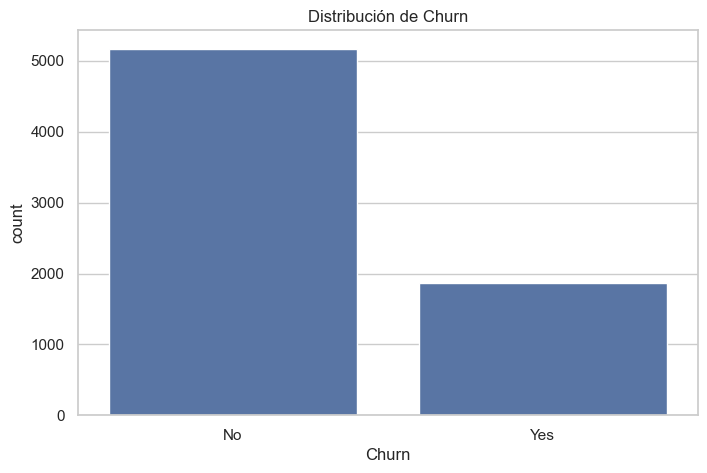

In [6]:
sns.countplot(x="Churn", data=df)
plt.title("Distribución de Churn")
plt.show()

### Step 5 — Missing values per column

`df.isnull().sum()` counts `NaN` values in each column. At this point all columns return 0 because `TotalCharges` has not yet been converted to numeric. The real missing values will surface after the conversion in Step 9.

### Step 6 — Churn distribution (countplot)

A countplot shows how many customers churned (`Yes`) vs stayed (`No`).

**Result:** ~5 000 stayed, ~1 900 churned — a roughly **73 % / 27 % split**. This imbalance is important: a naive classifier that always predicts 'No churn' would achieve 73 % accuracy without learning anything useful. We will address this with oversampling later.

**Why seaborn countplot?** `sns.countplot(x='Churn', data=df)` groups rows by the `Churn` column and draws one bar per category whose height equals the frequency. It is the fastest way to visualise a categorical distribution.

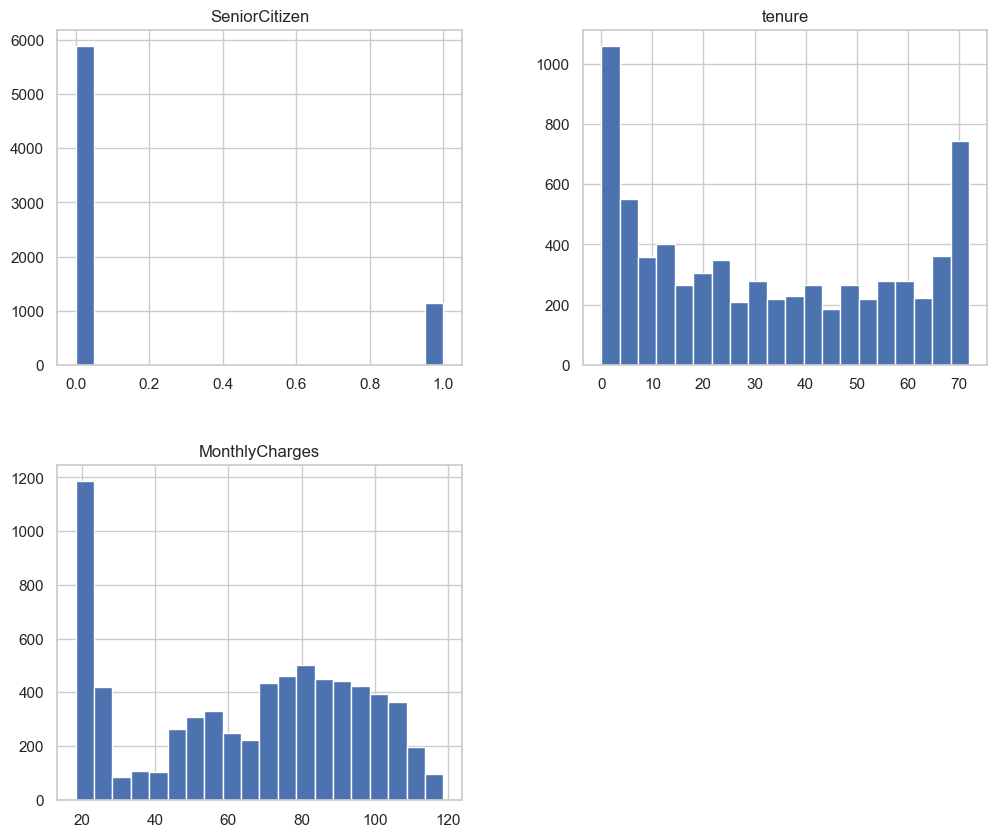

In [7]:
df.hist(bins=20, figsize=(12,10))
plt.show()

### Step 7 — Numeric feature distributions (histograms)

`df.hist(bins=20)` draws one histogram per numeric column.

**Key observation — `tenure`:** There is a spike in the first few months followed by a sharp drop, then a gradual accumulation of long-tenure customers. This bi-modal pattern tells us that many customers leave early; those who survive past ~20 months tend to stay much longer — they become loyal customers.

This pattern will be confirmed by the box-plot in Step 12, and it directly motivates `tenure` as one of the most predictive features in the model.

In [8]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


### Step 8 — Churn rate by contract type (crosstab)

`pd.crosstab(df['Contract'], df['Churn'], normalize='index')` computes, for each contract type, the proportion of customers who churned vs stayed.

**Result:**
| Contract | No churn | Churn |
|---|---|---|
| Month-to-month | 57 % | **43 %** |
| One year | 89 % | 11 % |
| Two year | 97 % | 3 % |

Customers on monthly plans churn at a dramatically higher rate. This makes intuitive sense — they have the lowest switching cost. Contract type will therefore be one of the strongest signals for the model.

**How `normalize='index'` works:** each row sums to 1.0, converting raw counts into percentages within each contract group.

In [9]:
df = df.drop("customerID", axis=1)



In [10]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### Step 9 — Drop customerID

`df.drop('customerID', axis=1)` removes the identifier column.

**Why?** `customerID` is a unique string for each row — it carries zero predictive signal and would interfere with one-hot encoding later. Dropping it with `axis=1` targets the column dimension (as opposed to `axis=0` which would drop rows).

In [11]:
df["TotalCharges"].head()

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: str

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

### Step 10 — Convert TotalCharges to numeric

`pd.to_numeric(df['TotalCharges'], errors='coerce')` parses the string column as floats.

**`errors='coerce'`:** Any value that cannot be converted (here, blank strings `" "`) becomes `NaN` instead of raising an exception. After this step `df.isnull().sum()` will reveal 11 missing values in `TotalCharges` — these correspond to brand-new customers (tenure = 0) who have no total charges yet.

In [13]:
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

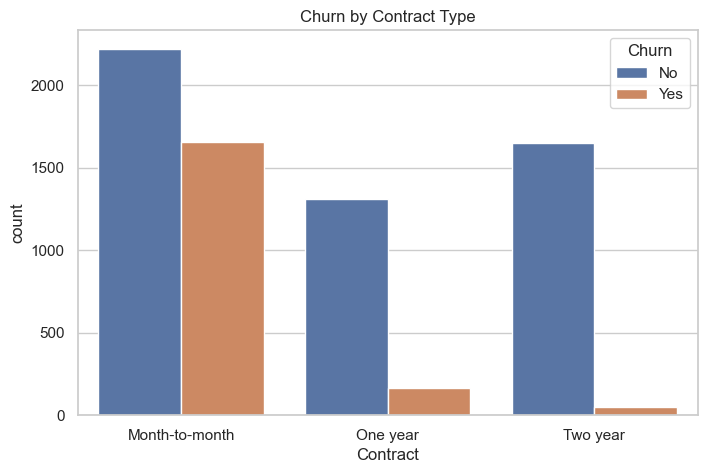

In [14]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.show()

### Seaborn plot cheat-sheet

| Goal | Function | Key arguments |
|---|---|---|
| One categorical variable | `countplot(x='Churn')` | — |
| One numeric variable | `histplot(x='MonthlyCharges')` | `bins=` |
| Two categorical variables | `countplot(x='Contract', hue='Churn')` | `hue=` |
| One categorical + one numeric | `boxplot(x='Contract', y='MonthlyCharges')` | — |
| Categorical + numeric + another categorical | `boxplot(x='Contract', y='MonthlyCharges', hue='Churn')` | — |

### Step 14 — Correlation heatmap

`sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')` shows pairwise Pearson correlations among all numeric columns (after encoding Churn as 0/1).

**Key observations:**
- `tenure` is **negatively correlated** with `Churn` (≈ −0.35): longer-tenured customers churn less.
- `MonthlyCharges` is **positively correlated** with `Churn` (≈ +0.19): higher bills → more churn.
- `TotalCharges` correlates strongly with `tenure` (≈ +0.83) — expected, since Total = Monthly × Tenure.

This gives us an initial feature ranking before fitting any model.

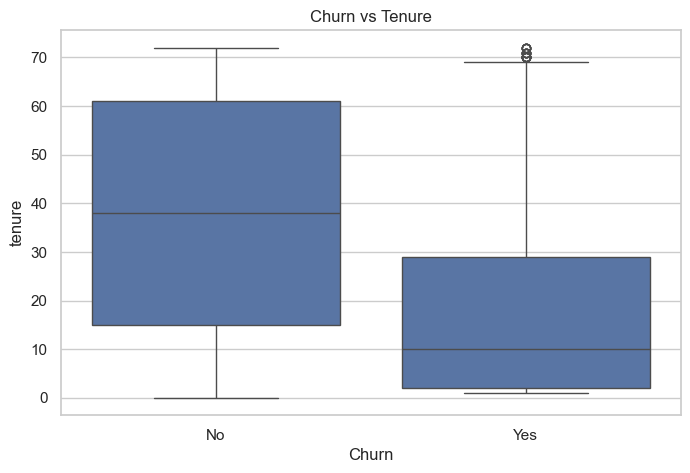

In [15]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Churn vs Tenure")
plt.show()

### Step 12 — Tenure vs Churn (box-plot)

A box-plot compares the distribution of `tenure` between customers who churned and those who stayed.

**Key finding:** Churned customers have a **much lower median tenure** (~10 months) than retained customers (~38 months). The interquartile ranges barely overlap, making `tenure` one of the most discriminative individual features in the dataset.

**Business interpretation:** The first few months are the most critical retention window. If a customer makes it past 1–2 years, they are significantly less likely to leave.

### Step 13 — Encode the target variable (Churn → 0/1)

Machine learning algorithms require numeric labels. We map `'Yes' → 1` and `'No' → 0` using `df['Churn'].map({'Yes': 1, 'No': 0})`.

**Why not use `LabelEncoder`?** For a binary target with known semantics it is cleaner and safer to use an explicit dictionary — there is no ambiguity about which class is 0 and which is 1.

In [16]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

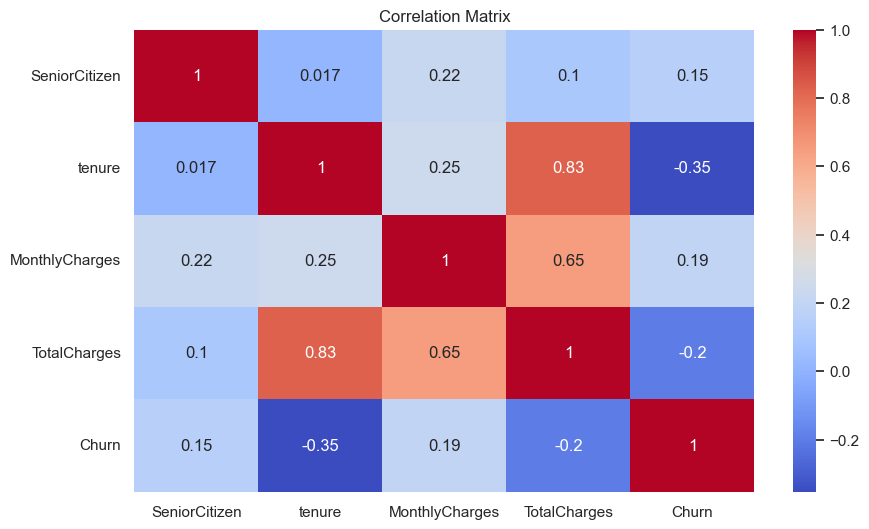

In [17]:
numeric_df = df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Step 11 — Missing values after conversion

After converting `TotalCharges` to numeric, 11 rows now have `NaN` in that column. These rows will be dropped with `df.dropna()` before modelling to keep the dataset clean. Dropping only 11 rows out of 7 043 (< 0.2 %) has negligible impact on model quality.

In [18]:
X = df.drop("Churn", axis=1) # eliminar la columna de Churn para usarla como variable objetivo
y = df["Churn"]    # asignar la columna de Churn a y
X = pd.get_dummies(X) # convertir variables categóricas a numéricas usando one-hot encoding

In [19]:
df = df.dropna()

X = df.drop("Churn", axis=1)
y = df["Churn"]

X = pd.get_dummies(X)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)


from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Step 15 — Prepare features and labels (X, y) + One-Hot Encoding

```python
X = df.drop('Churn', axis=1)   # All columns except the target
y = df['Churn']                # Target (0 or 1)
X = pd.get_dummies(X)          # One-hot encode all categorical columns
```

**`pd.get_dummies`** converts each categorical column (e.g. `Contract`) into binary dummy columns (e.g. `Contract_Month-to-month`, `Contract_One year`, `Contract_Two year`). This is required because logistic regression and most sklearn estimators expect numeric input.
The image above shows the train / test split with `test_size=0.2` and `random_state=42`, meaning 80 % of rows go to training and 20 % to testing, with a fixed random seed for reproducibility.
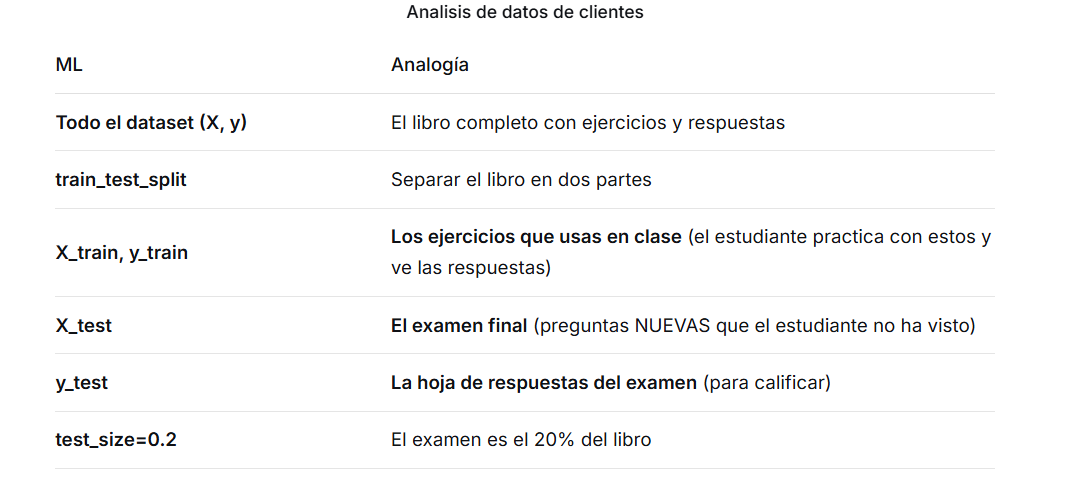

In [20]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7882018479033405


In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[916 117]
 [181 193]]


In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.767590618336887


In [24]:
from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7775408670931059


### Step 16 — Model comparison (before scaling)

Three baseline classifiers are trained on the raw (unscaled) features:

| Model | Accuracy |
|---|---|
| **Logistic Regression** | **0.788** |
| Random Forest | 0.777 |
| KNN | 0.767 |

Logistic Regression wins at this stage. Note that accuracy alone can be misleading with imbalanced classes — we will examine precision/recall in later steps.

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LogisticRegression

model_scaled = LogisticRegression(max_iter=5000)

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

In [27]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Scaled Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_scaled))
print(classification_report(y_test, y_pred_scaled))

Scaled Logistic Regression Accuracy: 0.7874911158493249
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5
)

grid.fit(X_train_scaled, y_train)

print("Best parameter:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Best parameter: {'C': 10}
Best cross-validation score: 0.8071111111111111


In [29]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

from sklearn.metrics import accuracy_score
print("Optimized Accuracy:", accuracy_score(y_test, y_pred_best))

Optimized Accuracy: 0.7889125799573561


In [30]:
df["Churn"].value_counts(normalize=True)

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

In [31]:
from sklearn.utils import resample

# unir X y y
df_balanced = X_train.copy()
df_balanced["Churn"] = y_train

# separar clases
df_majority = df_balanced[df_balanced["Churn"] == 0]
df_minority = df_balanced[df_balanced["Churn"] == 1]

# oversampling
df_minority_upsampled = resample(
    df_minority,
    replace=True,
    n_samples=len(df_majority),
    random_state=42
)

# combinar
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# separar de nuevo
X_train_bal = df_upsampled.drop("Churn", axis=1)
y_train_bal = df_upsampled["Churn"]

In [32]:
from sklearn.linear_model import LogisticRegression 
model= LogisticRegression(max_iter=5000)
model.fit(X_train_bal, y_train_bal)
y_pred_bal = model.predict(X_test_scaled)

c:\Users\elija\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.87      0.55      0.67      1033
           1       0.38      0.78      0.51       374

    accuracy                           0.61      1407
   macro avg       0.63      0.66      0.59      1407
weighted avg       0.74      0.61      0.63      1407



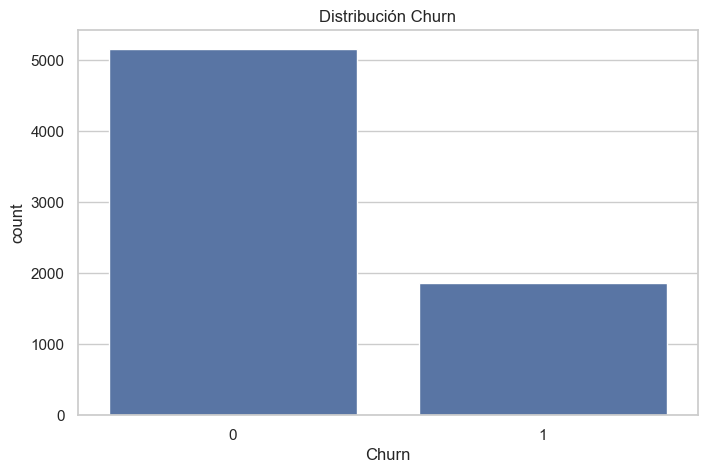

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt 

sns.countplot(x="Churn", data=df)
plt.title("Distribución Churn")
plt.show()

Text(0.5, 1.0, 'Churn vs Tenure')

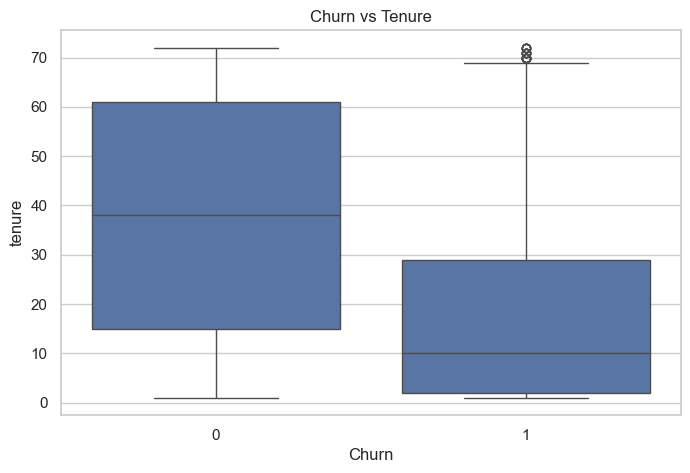

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot( x= "Churn", y="tenure",data=df)
plt.title("Churn vs Tenure")

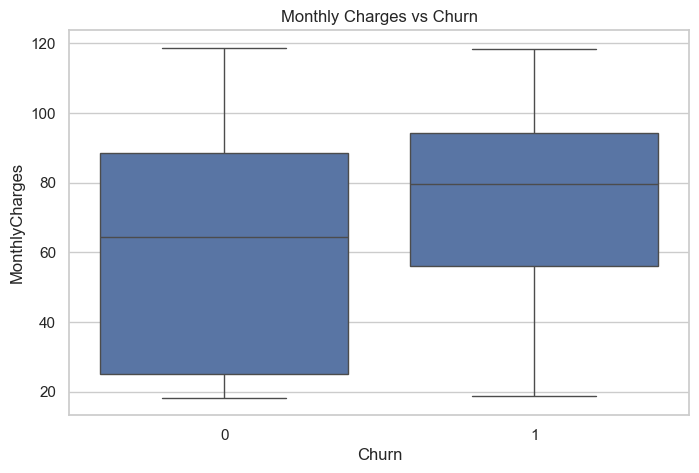

In [36]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

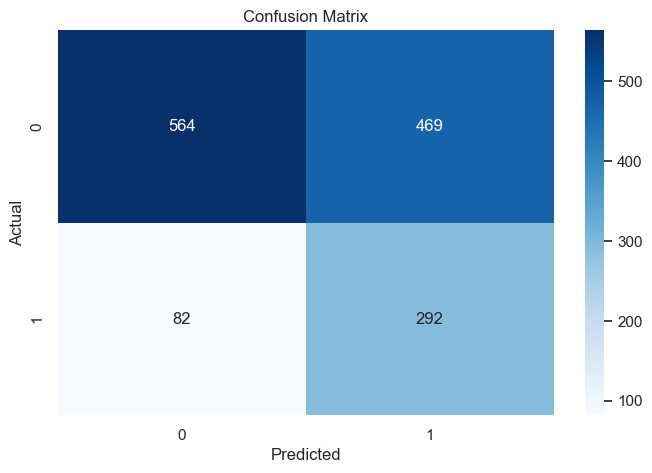

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_bal)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [38]:
y_probs = model.predict_proba(X_test)[:, 1]
pd.DataFrame({"Actual": y_test, "Predicted_Prob": y_probs}).head()

,Actual,Predicted_Prob
2481,0,0.013878
6784,0,0.307251
6125,1,0.828647
3052,0,0.224894
4099,0,0.637613


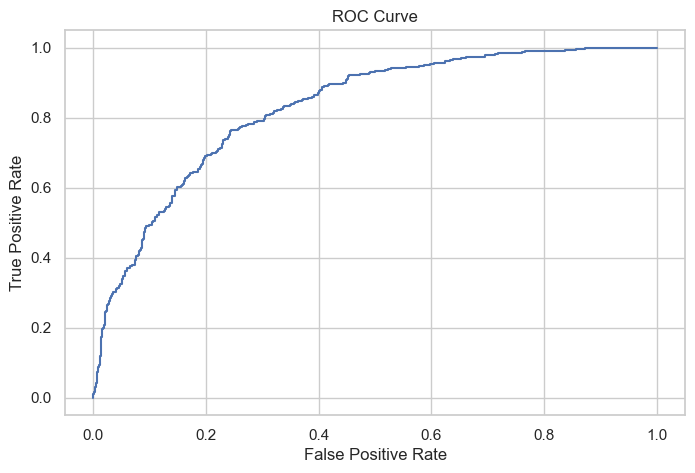

AUC: 0.8284965134518122


In [39]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

In [40]:
threshold = 0.3

y_pred_custom = (y_probs >= threshold).astype(int)


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.94      0.55      0.70      1033
           1       0.42      0.90      0.58       374

    accuracy                           0.65      1407
   macro avg       0.68      0.73      0.64      1407
weighted avg       0.80      0.65      0.66      1407



In [42]:
for t in [0.3, 0.4, 0.5, 0.6]:
    y_pred_t = (y_probs >= t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_test, y_pred_t))
    print("------")

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.94      0.55      0.70      1033
           1       0.42      0.90      0.58       374

    accuracy                           0.65      1407
   macro avg       0.68      0.73      0.64      1407
weighted avg       0.80      0.65      0.66      1407

------
Threshold: 0.4


              precision    recall  f1-score   support

           0       0.92      0.62      0.74      1033
           1       0.45      0.85      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.80      0.69      0.70      1407

------
Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407

------
Threshold: 0.6
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1033
           1       0.54      0.70      0.61       374

    accuracy                           0.76      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0

In [43]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted_Prob": y_probs
})

results.to_csv("churn_predictions.csv", index=False)